In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import pennylane as qp
from pennylane import numpy as np
from sklearn.model_selection import train_test_split

In [23]:
L = 3     # number of layers W_i M
n_qubits = n_nodes = 4
dev = qp.device("default.qubit", wires=n_qubits)

### PQC

In [40]:
def data_encoding_circuit_block(ising_hamiltonian):
    qp.evolve(ising_hamiltonian, -1.0)

def variational_layer(theta):
    for i in range(n_qubits):
        qp.RX(theta[0], wires=i)
        qp.RY(theta[1], wires=i)

@qp.qnode(dev)
def pqc(theta_params, H_G):
    for j in range(L):
        data_encoding_circuit_block(H_G)
        variational_layer(theta_params[j])

    return qp.probs(wires=range(n_qubits))

In [41]:
def get_ising_hamiltonian(A):
    coeffs = []
    obs = []
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            if A[i, j] == 1:
                coeffs.append(1.)
                obs.append(qp.PauliZ(i) @ qp.PauliZ(j))
    if len(obs) == 0:
        return 0.0 * qp.Identity(0)
    return qp.Hamiltonian(coeffs, obs)

### Metrics

In [42]:
def bce_loss(theta_params, H_G, y):
    probs = pqc(theta_params, H_G)
    prediction = probs[0]

    eps = 1e-15
    pred_clipped = qp.math.clip(prediction, eps, 1.0 - eps)

    return -(y * qp.math.log(pred_clipped) + (1 - y) * qp.math.log(1 - pred_clipped))

def cost_function(theta_params, dataset=None):
    losses = []

    for _, H, y in dataset:
        loss_value = bce_loss(theta_params, H, y)
        losses.append(loss_value)

    return qp.math.mean(qp.math.stack(losses))

def compute_accuracy(theta_params, dataset):
    correct_predictions = 0

    for _, H, y in dataset:
        probs = pqc(theta_params, H_G)
        prediction = probs[0]
        discrete_pred = 1 if prediction >= 0.5 else 0
        if discrete_pred == y:
            correct_predictions += 1

    return correct_predictions / len(dataset)

### Data Generation

In [43]:
N = 100
dataset = []

n_nodes = n_qubits
threshold = np.log(n_nodes) / n_nodes   # The theoretical threshold for a graph to be connected is ln(n)/n
edge_probabilities = [random.uniform(threshold*0.5, threshold*1.5) for _ in range(N)]

for p in edge_probabilities:
    G = nx.erdos_renyi_graph(n=n_nodes, p=p)
    A = nx.to_numpy_array(G)
    H_G = get_ising_hamiltonian(A)
    y = 0 if nx.is_connected(G) else 1
    dataset.append((A, H_G, y))

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

### Training

Starting Training...
Epoch   1 | Train Loss: 1.2293 | Train Acc: 0.40 | Test Loss: 1.4516 | Test Acc: 0.40
Epoch   5 | Train Loss: 1.1270 | Train Acc: 0.40 | Test Loss: 1.2390 | Test Acc: 0.40
Epoch  10 | Train Loss: 1.1084 | Train Acc: 0.40 | Test Loss: 1.1392 | Test Acc: 0.40
Epoch  15 | Train Loss: 1.0693 | Train Acc: 0.40 | Test Loss: 1.0654 | Test Acc: 0.40
Epoch  20 | Train Loss: 0.9640 | Train Acc: 0.60 | Test Loss: 0.9423 | Test Acc: 0.60
Epoch  25 | Train Loss: 0.6806 | Train Acc: 0.60 | Test Loss: 0.7370 | Test Acc: 0.60
Epoch  30 | Train Loss: 0.5969 | Train Acc: 0.60 | Test Loss: 0.8969 | Test Acc: 0.60
Epoch  35 | Train Loss: 0.3564 | Train Acc: 0.60 | Test Loss: 0.7715 | Test Acc: 0.60
Epoch  40 | Train Loss: 0.3912 | Train Acc: 0.60 | Test Loss: 0.7059 | Test Acc: 0.60
Epoch  45 | Train Loss: 0.3994 | Train Acc: 0.60 | Test Loss: 0.6438 | Test Acc: 0.60
Epoch  50 | Train Loss: 0.3686 | Train Acc: 0.60 | Test Loss: 0.6670 | Test Acc: 0.60

Final Optimized Parameters (thet

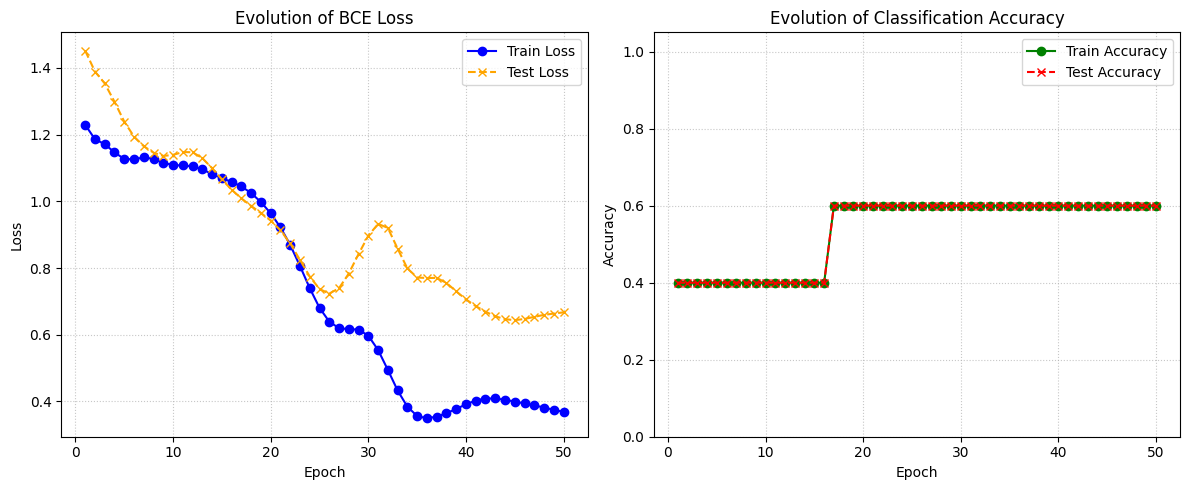

In [48]:
epochs = 50

np.random.seed(42)
thetas = np.random.uniform(0, 2*np.pi, size=(L, 2), requires_grad=True)

opt = qp.AdamOptimizer(stepsize=0.1)

history_train_loss = []
history_test_loss = []
history_train_acc = []
history_test_acc = []

print("Starting Training...")

for epoch in range(epochs):
    # Optimizer step
    objective_fn = lambda t: cost_function(t, dataset=train_data)
    thetas = opt.step(objective_fn, thetas)

    train_loss = cost_function(thetas, dataset=train_data)
    train_acc = compute_accuracy(thetas, dataset=train_data)

    test_loss = cost_function(thetas, dataset=test_data)
    test_acc = compute_accuracy(thetas, dataset=test_data)

    # Store the metrics
    history_train_loss.append(train_loss)
    history_test_loss.append(test_loss)
    history_train_acc.append(train_acc)
    history_test_acc.append(test_acc)

    # We still only print every 5 epochs so the console doesn't get too messy
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:3d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}")

print("\nFinal Optimized Parameters (thetas):", thetas)

# ==========================================
# --- NEW: Plotting the results ---
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: BCE Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history_train_loss, label='Train Loss', marker='o', color='blue')
plt.plot(range(1, epochs + 1), history_test_loss, label='Test Loss', marker='x', linestyle='--', color='orange')
plt.title('Evolution of BCE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history_train_acc, label='Train Accuracy', marker='o', color='green')
plt.plot(range(1, epochs + 1), history_test_acc, label='Test Accuracy', marker='x', linestyle='--', color='red')
plt.title('Evolution of Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.05) # Accuracy is strictly between 0 and 1
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Evaluating final model on test data for Confusion Matrix...


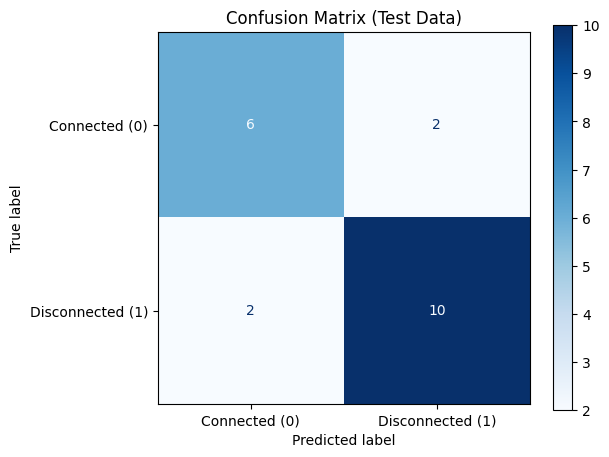

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Collect true labels and predictions
true_labels = []
predicted_labels = []

print("Evaluating final model on test data for Confusion Matrix...")

for A_i, H_i, y_i in test_data:
    # Store the true label
    true_labels.append(y_i)

    # Get the model's prediction
    # (Assuming gamma is handled inside your circuit or passed as a kwarg)
    probs = pqc(thetas, H_i)
    continuous_pred = probs[0]

    # Threshold the probability to get a hard 0 or 1 classification
    discrete_pred = 1 if continuous_pred >= 0.5 else 0
    predicted_labels.append(discrete_pred)

# 2. Compute the Confusion Matrix
# labels=[0, 1] ensures the matrix is always 2x2 even if the test set is missing a class
cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

# 3. Plot it beautifully
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Connected (0)', 'Disconnected (1)']
)

# You can change 'Blues' to 'Greens', 'Purples', etc.
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix (Test Data)')
plt.show()